In [48]:
import sys
sys.path.insert(0, 'c:/Users/elois/OneDrive - University of Bristol/Documents/GitHub/mdm2_project2')
import os
os.chdir('c:/Users/elois/OneDrive - University of Bristol/Documents/GitHub/mdm2_project2')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
FISH_ATTRS = 3 #(x,y, heading)


In [ ]:
#from turn around detection
#returns the angle of a given position
def get_angles(x,y) -> np.typing.NDArray :
    
    x = np.array(x)
    y = np.array(y)

    theta = np.arctan2(x,y)

    theta %= np.pi*2

    return theta

In [ ]:
#from turn around detection
def find_turning_points(x:np.typing.NDArray,y:np.typing.NDArray) -> list[tuple[int,int]] :

    '''
    find turning points in the movements of a fish , 
    given its x and y coords , will return a list of
    timestamps of detections of turnarounds.
    '''

    theta = np.arctan2(x,y)  #angle with horizontal 
    theta %= np.pi*2

    raw_diff = theta[1:] - theta[:-1]

    # find places where the diff is more than 180 degrees 
    # as that means that there was a wrap around 

    mod_diff = raw_diff % np.pi 

    mod_p1_diff = mod_diff - np.pi # incase the diff is in the other direction i.e 179 instead of -1 deg

    diff = np.array([

        v if abs(mod_p1_diff[i]) > v else mod_p1_diff[i]
        for i,v in enumerate(mod_diff)

    ])

    turn_arounds = []
    for start in np.where(np.diff(np.sign(diff)))[0] :
        turn_arounds.append((start,start+1))

    return turn_arounds

In [ ]:
#calculating e=v/mod v
#unit velocity vector

#frames= 200 frame chunk of the data
def get_unit_vectors(frames) -> list[np.ndarray]:
    vectors = [] 
    for fish_i in range(0, frames.shape[1], FISH_ATTRS):
        x = frames.iloc[:, fish_i].values
        y = frames.iloc[:, fish_i + 1].values

        #displacement per frame
        vx = np.diff(x)
        vy = np.diff(y)

        #mod v—speed at each frame
        speed = np.sqrt(vx**2 + vy**2)

        #avoid division by zero when fish is stationary
        speed[speed == 0] = np.nan

        #e_i = v/mod v
        ex=vx/speed
        ey=vy/speed

        vectors.append(np.column_stack((ex, ey))) #final vector e

    return vectors


In [ ]:
def Hij(ei: np.ndarray, ej: np.ndarray, delay: int) -> np.ndarray:
    '''
    H_ij(t, tau) = e_i(t) . e_j(t - tau)
    '''
    T = ei.shape[0]
    #e_i(t) . e_j(t - delay) for all t
    return (ei[delay:, 0] * ej[:T - delay, 0]) + (ei[delay:, 1] * ej[:T - delay, 1])

In [ ]:
#w needs to be changed depending on noise of the data, w=2 is used in paper
def Cij(ei: np.ndarray, ej: np.ndarray, delay: int, w: int = 2) -> np.ndarray:
    
    #C_ij(t, tau, w) = 1/(2w+1) * sum_{k=-w}^{w} H_ij(t + k, tau)
    #Smoothed version of H_ij over (2w+1) frames.
    
    h= Hij(ei, ej, delay)
    window= 2*w + 1

    if len(h) < window:
        return np.array([])
    #cumulative sum
    sum = np.concatenate(([0], np.cumsum(h)))
    smooth = (sum[window:] - sum[:-window]) / window
    return smooth

In [55]:
#ploarization
def polarisation(vectors: list[np.ndarray]) -> np.ndarray:
    N = len(vectors)
    summed = np.sum(vectors, axis=0)  #sum unit vectors across fish
    return np.linalg.norm(summed, axis=1) / N 

In [ ]:
FPS = 50
DT = 1 / FPS

def compute_Cij_matrix(ei: np.ndarray, ej: np.ndarray, max_delay: float = 2.0, w: int = 2):
    delay_range = np.arange(2, int(max_delay * FPS) + 1)
    T = ei.shape[0]
    n_time = T - int(max_delay * FPS) - 2 * w
    
    #positive delay meaning fish i copying fish j
    C_pos = []
    for delay in delay_range:
        row = Cij(ei, ej, delay, w)
        #pad with nan to full length
        padded = np.full(n_time, np.nan)
        padded[:len(row)] = row[:n_time]
        C_pos.append(padded)
    
    #negative delay meaning fish j copying fish i
    C_neg = []
    for delay in delay_range:
        row = Cij(ej, ei, delay, w)
        padded = np.full(n_time, np.nan)
        padded[:len(row)] = row[:n_time]
        C_neg.append(padded)
    
    C_pos = np.array(C_pos)
    C_neg = np.array(C_neg)
    
    C_matrix = np.vstack([np.flipud(C_neg), C_pos])
    delays_s = np.concatenate([-delay_range[::-1] * DT, delay_range * DT])
    
    return C_matrix, delays_s

In [ ]:
def plot_heatmap(C: np.ndarray, delays_s: np.ndarray, fish_i: int, fish_j: int, ax: plt.Axes = None):
    n_time = C.shape[1]
    t_axis = np.arange(n_time)*DT
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(C, aspect='auto', origin='lower',
                   extent=[t_axis[0], t_axis[-1], delays_s[0], delays_s[-1]],
                   vmin=-1, vmax=1, cmap='seismic')
    best_delay = delays_s[int(np.argmax(C.mean(axis=1)))]
    ax.axhline(best_delay, color='blue', linewidth=1.2, linestyle='--', label=f'delay* = {best_delay:.2f}s')
    plt.colorbar(im, ax=ax, label='C_ij')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Delay (s)')
    ax.set_title(f'Fish {fish_i + 1} copying Fish {fish_j + 1}  (delay* = {best_delay:.2f}s)')
    ax.legend(fontsize=8)
    return ax

In [86]:
def plot_sensitivity(ei: np.ndarray, ej: np.ndarray, fish_i: int, fish_j: int, delay: int = 10):
    #test w values from 0 to 10
    w_values = range(0, 11)
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    axes_flat = axes.flatten()
    
    for idx, w in enumerate(w_values):
        c = Cij(ei, ej, delay, w)
        t_axis = np.arange(len(c)) * DT
        axes_flat[idx].plot(t_axis, c)
        axes_flat[idx].axhline(0, color='black', linewidth=0.5)
        axes_flat[idx].set_ylim(-1, 1)
        axes_flat[idx].set_title(f'w = {w}')
        axes_flat[idx].set_xlabel('Time (s)')
        axes_flat[idx].set_ylabel('C_ij')
    
    for ax in axes_flat[len(w_values):]:
        ax.set_visible(False)
    
    fig.suptitle(f'Sensitivity analysis: Fish {fish_i + 1} copying Fish {fish_j + 1} at delay = {delay * DT:.2f}s')
    plt.tight_layout()
    plt.show()

In [59]:
def split_at_nans_vectorized(data: pd.DataFrame) -> list[pd.DataFrame]:
    """Splits data into contiguous chunks, breaking at any NaN values."""
    
    # 1. Create a boolean mask: True if any NaN exists in the row
    is_nan = data.isna().any(axis=1)
    
    # 2. Create unique group IDs. 
    # The cumulative sum increases by 1 every time it hits a NaN row.
    # This automatically assigns the same integer to contiguous blocks of valid data.
    block_ids = is_nan.cumsum()
    
    # 3. Filter out the actual NaN rows from both the data and the IDs
    valid_data = data[~is_nan]
    valid_block_ids = block_ids[~is_nan]
    
    # 4. Group by the IDs and extract the DataFrames as a list
    data_blocks = [group for _, group in valid_data.groupby(valid_block_ids)]
    
    return data_blocks

turns found: 132


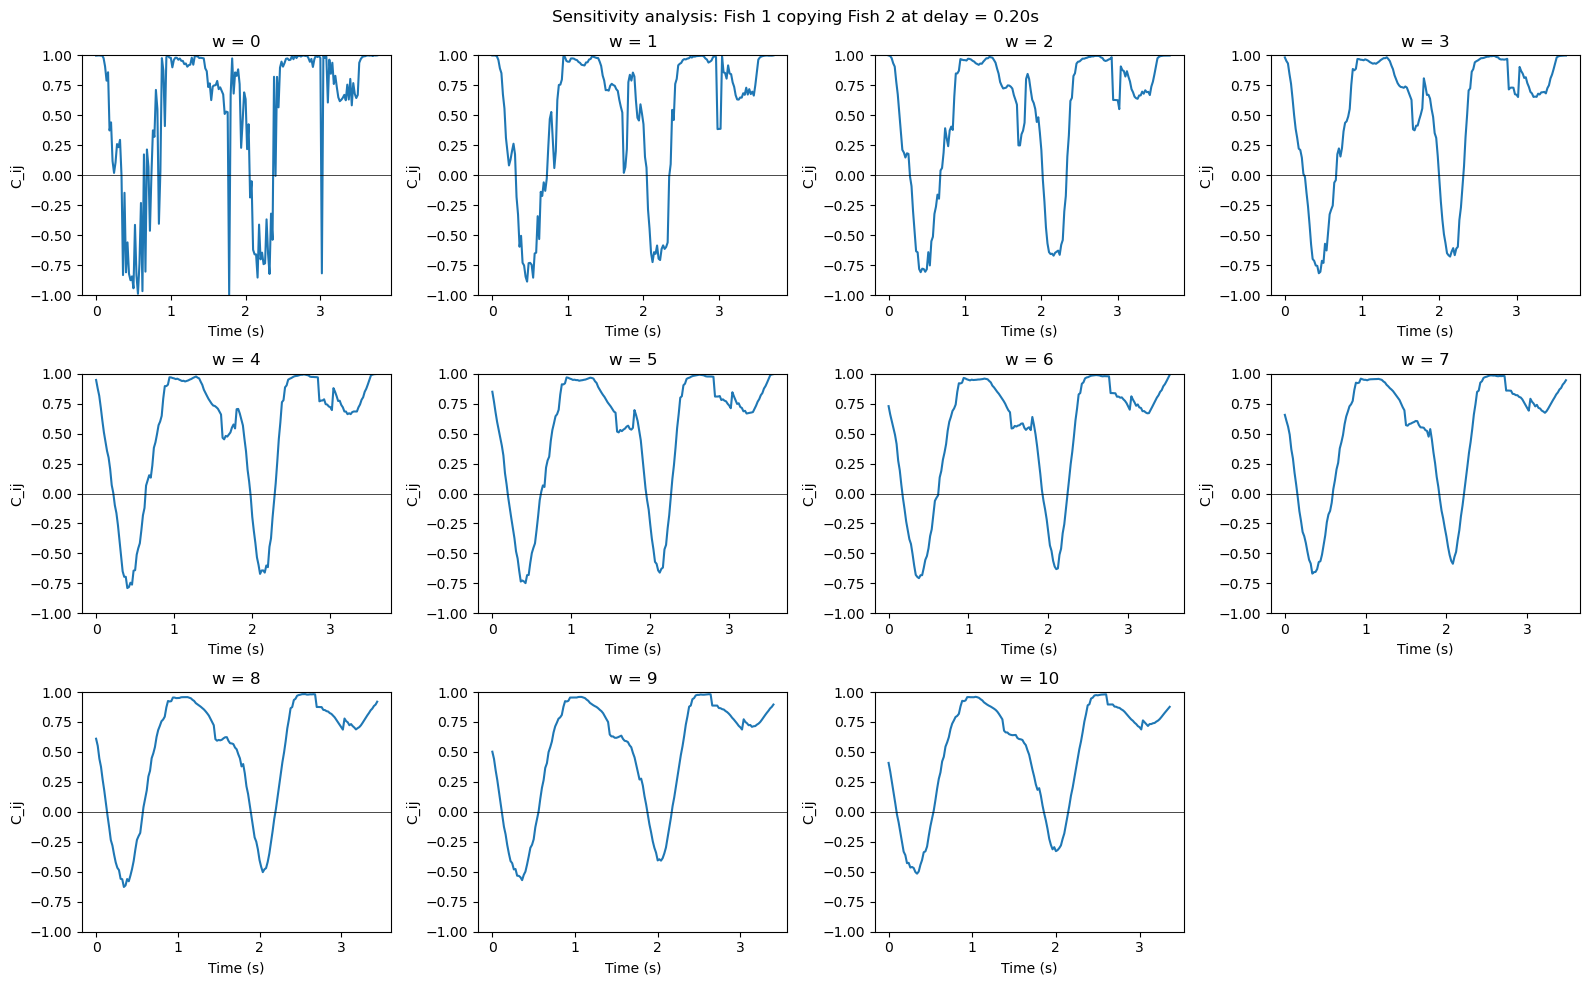

In [ ]:
if __name__ == '__main__':
    from data_access import get_experement_paths, split_at_nans

    #accessing the data
    data_path= get_experement_paths(group_size=5, limit=1)[0]
    data= pd.read_csv(data_path)
    clean_data= split_at_nans(data)

    chunk= max(clean_data, key=len)
    chunk= chunk.reset_index(drop=True)

    #find a U-turn
    x0= chunk.iloc[:, 0].values
    y0= chunk.iloc[:, 1].values
    turns = find_turning_points(x0, y0)
    print(f'turns found: {len(turns)}')

    #200 frames around the 18th turn
    turn_frame= turns[18][0] #selecting turn
    window= chunk.iloc[turn_frame - 100 : turn_frame + 100] #100 frames either side

    vectors= get_unit_vectors(window)
    n_fish= len(vectors)

    plot_sensitivity(vectors[0], vectors[1], 0, 1)

    #plotting heatmap

    # pairs = [(i, j) for i in range(n_fish) for j in range(n_fish) if i != j]
    # ncols = 4
    # nrows = int(np.ceil(len(pairs) / ncols))
    # fig, axes = plt.subplots(nrows, ncols, figsize=(10 * ncols, 5 * nrows))
    # axes_flat = axes.flatten()

    # for idx, (i, j) in enumerate(pairs):
    #     C, delays_s = compute_Cij_matrix(vectors[i], vectors[j])
    #     plot_heatmap(C, delays_s, i, j, ax=axes_flat[idx])

    # for ax in axes_flat[len(pairs):]:
    #     ax.set_visible(False)

    # plt.tight_layout()
    # plt.show()


turns found: 132


C:\Users\elois\AppData\Local\Temp\ipykernel_10260\2003962671.py:33: RuntimeWarning: Mean of empty slice
  best_tau = taus_s[int(np.argmax(np.nanmean(C, axis=1)))]


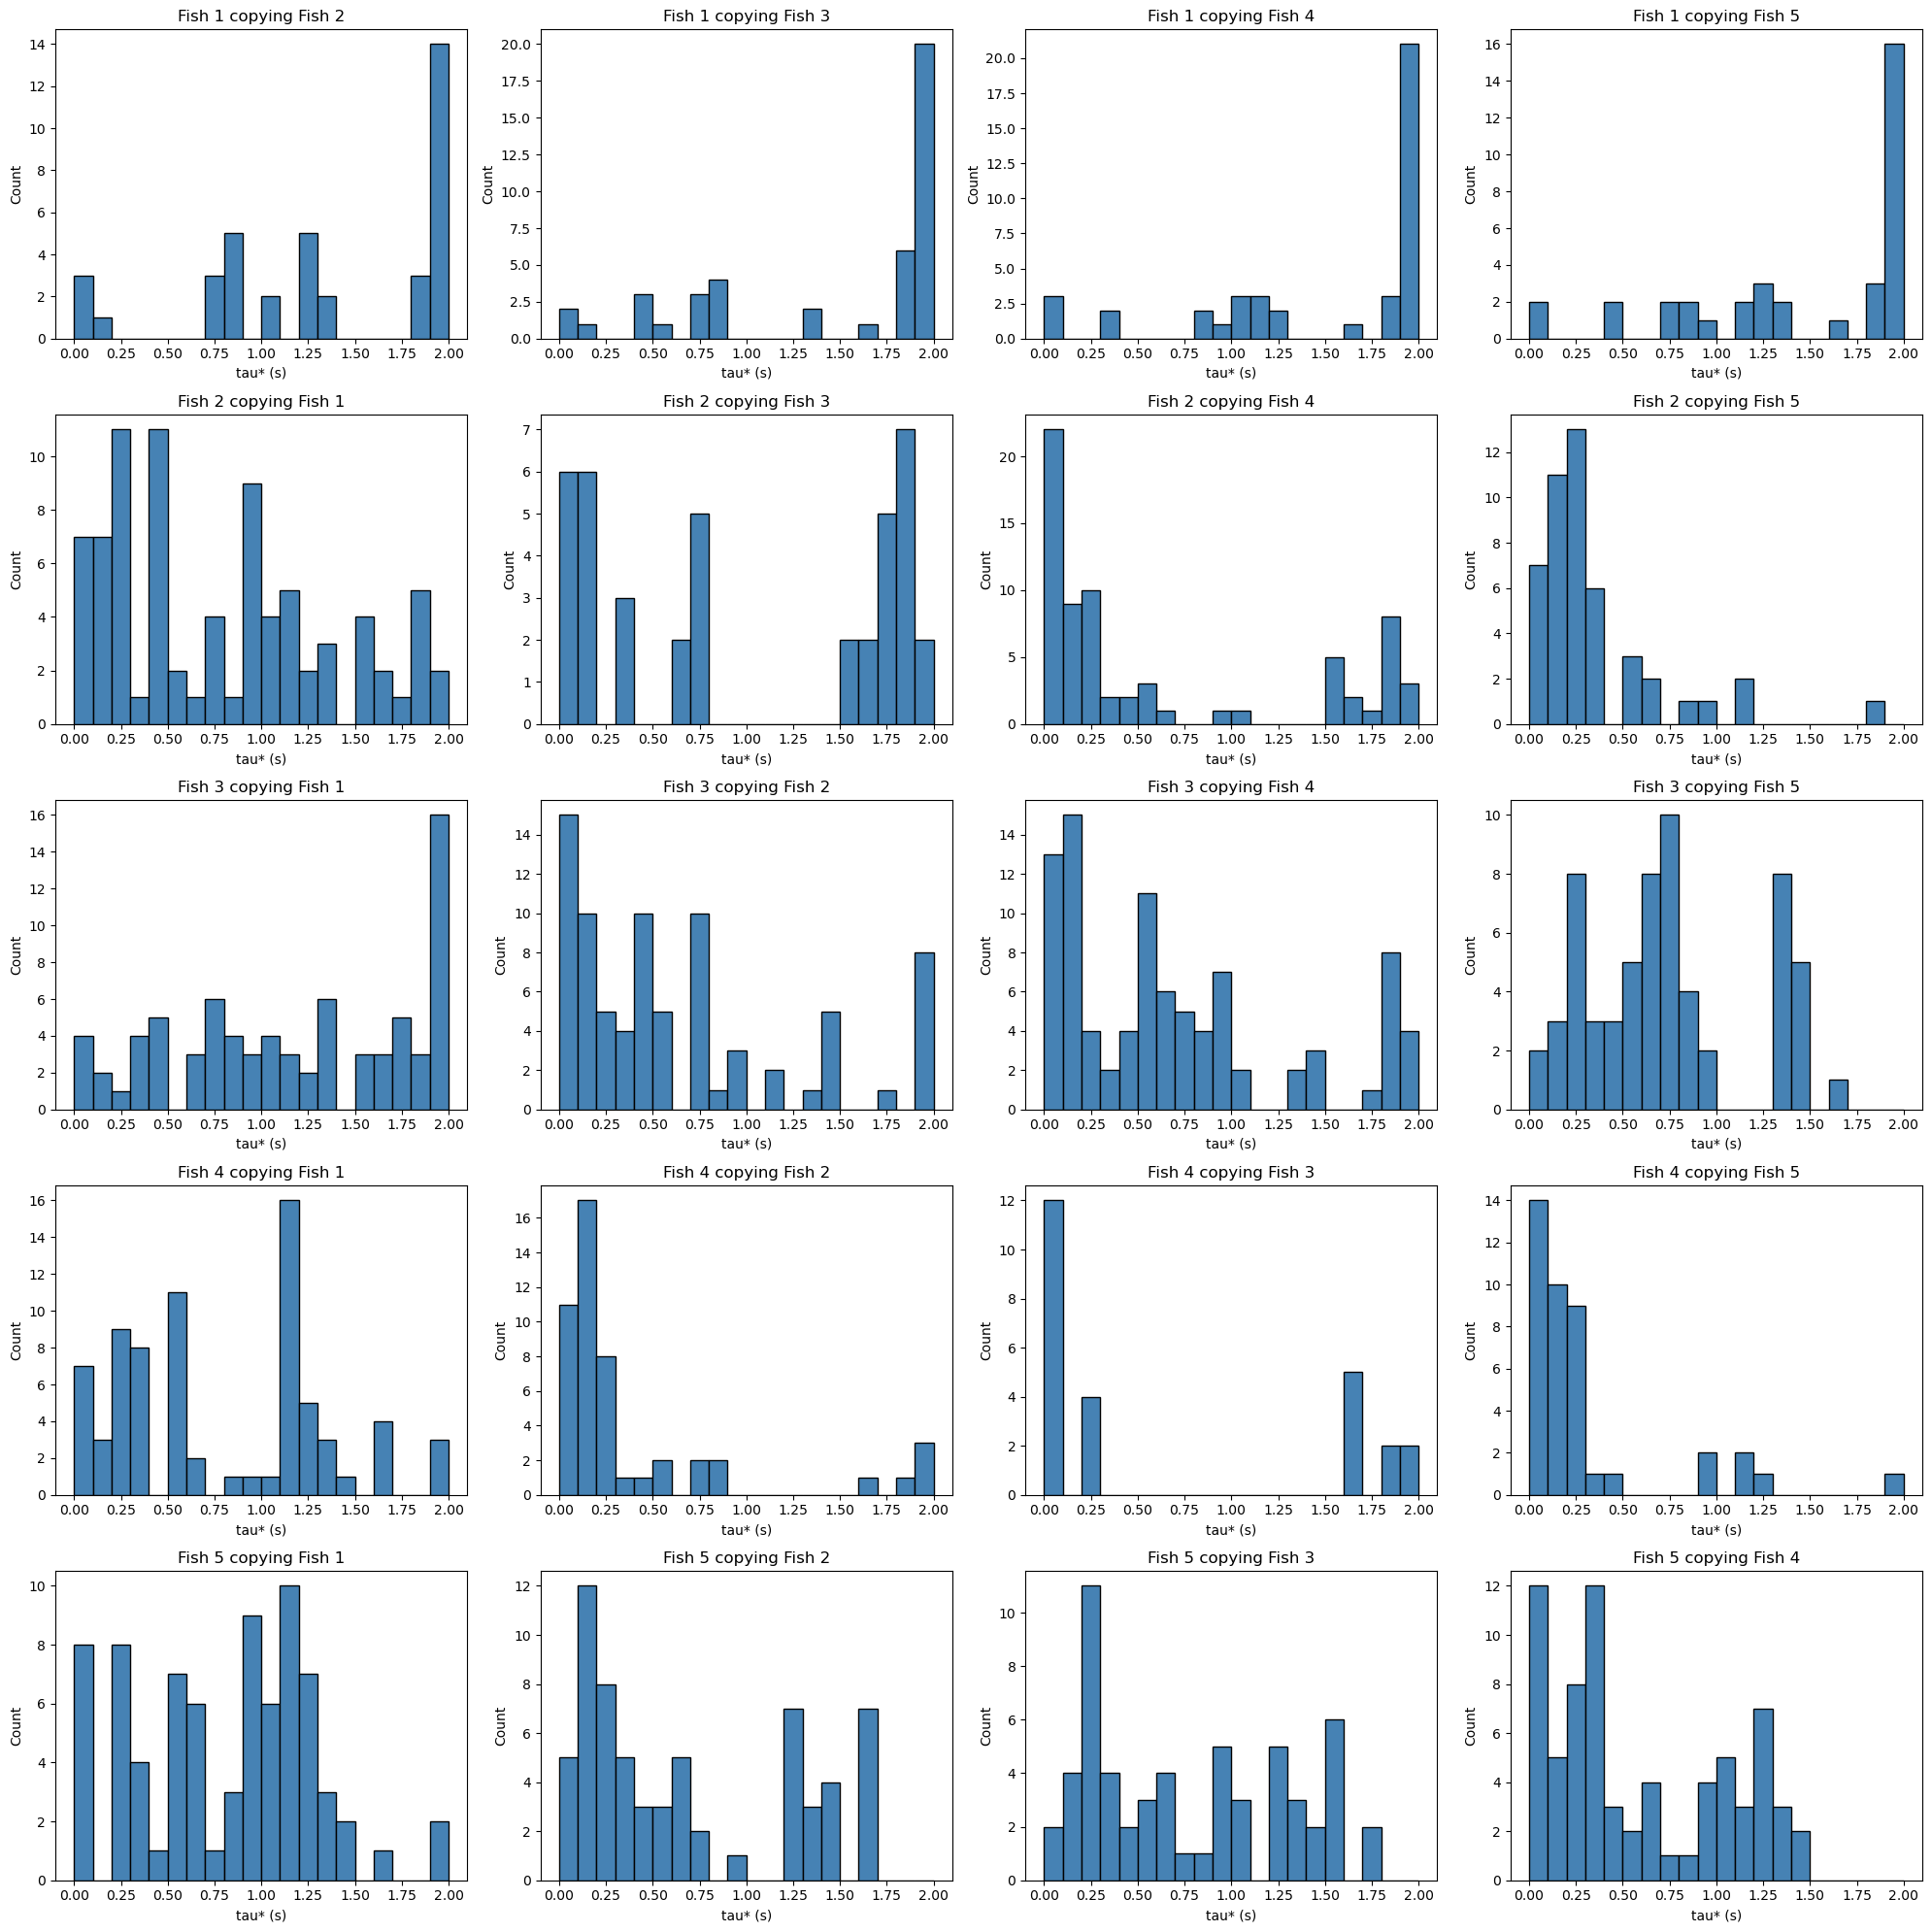

In [ ]:
#histograms
if __name__ == '__main__':
    #using data access file 
    from data_access import get_experement_paths, split_at_nans

    data_path= get_experement_paths(group_size=5, limit=1)[-1]
    data= pd.read_csv(data_path)
    clean_data= split_at_nans(data)

    chunk= max(clean_data, key=len)
    chunk= chunk.reset_index(drop=True)

    x0= chunk.iloc[:, 0].values
    y0= chunk.iloc[:, 1].values
    turns= find_turning_points(x0, y0) #number of turns detected
    print(f'turns found: {len(turns)}')

    #collect delay* for every pair across all turns
    all_delays = {(i, j): [] for i in range(5) for j in range(5) if i != j}

    for turn_start, _ in turns:
        if turn_start < 100 or turn_start + 100 > len(chunk):
            continue

        window  = chunk.iloc[turn_start - 100 : turn_start + 100]
        vectors = get_unit_vectors(window)

        for i in range(5):
            for j in range(5):
                if i == j:
                    continue
                C, delays_s = compute_Cij_matrix(vectors[i], vectors[j])
                if C.size == 0 or np.isnan(C).all():
                    continue
                best_delay = delays_s[int(np.argmax(np.nanmean(C, axis=1)))]
                all_delays[(i, j)].append(best_delay)

    #plot histogram of delay* for each pair of fish
    pairs = list(all_delays.keys())
    ncols = 4
    nrows = int(np.ceil(len(pairs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes_flat = axes.flatten()

    for idx, (i, j) in enumerate(pairs):
        axes_flat[idx].hist(all_delays[(i, j)], bins=20, range=(0, 2),
                            color='steelblue', edgecolor='black')
        axes_flat[idx].set_title(f'Fish {i+1} copying Fish {j+1}')
        axes_flat[idx].set_xlabel('delay* (s)')
        axes_flat[idx].set_ylabel('Count')

    for ax in axes_flat[len(pairs):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

In [ ]:
#Fish 1 copying Fish 2, 4 and 5 was strongly peaked at tau* = 0.04s, suggesting Fish 1 is a leader rather than a follower.
#Fish 2 copying Fish 1 showed a broader distribution with a peak around 0.25s, indicating Fish 2 follows Fish 1 with a real delay.
#Fish 3 copying Fish 1 and 2 showed broad flat distributions, suggesting Fish 3 does not consistently follow any individual.
#Fish 4 copying Fish 3 and Fish 5 copying Fish 3 both showed very sharp peaks at tau* = 0.04s, indicating strong following behaviour.
#The spike at the minimum delay across many pairs may reflect genuine near-instant copying or noise; the paper filters these out using a reaction time threshold.

turns found: 20830


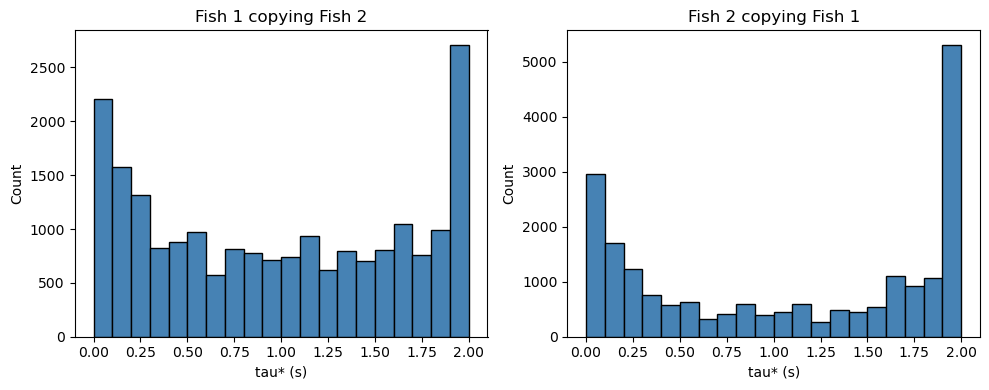

In [ ]:
#same for 2 fish
if __name__ == '__main__':
    from data_access import get_experement_paths, split_at_nans

    data_path= get_experement_paths(group_size=2, limit=1)[0]
    data= pd.read_csv(data_path)
    clean_data= split_at_nans(data)

    chunk= max(clean_data, key=len)
    chunk= chunk.reset_index(drop=True)

    x0= chunk.iloc[:, 0].values
    y0= chunk.iloc[:, 1].values
    turns = find_turning_points(x0, y0)
    print(f'turns found: {len(turns)}')

    all_delays= {(i, j): [] for i in range(2) for j in range(2) if i != j}

    for turn_start, _ in turns:
        if turn_start < 100 or turn_start + 100 > len(chunk):
            continue

        window= chunk.iloc[turn_start - 100 : turn_start + 100]
        vectors= get_unit_vectors(window)

        for i in range(2):
            for j in range(2):
                if i == j:
                    continue
                C, delays_s = compute_Cij_matrix(vectors[i], vectors[j])
                if C.size == 0 or np.isnan(C).all():
                    continue
                best_delay = delays_s[int(np.argmax(np.nanmean(C, axis=1)))]
                all_delays[(i, j)].append(best_delay)

    pairs = list(all_delays.keys())
    fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4))

    for idx, (i, j) in enumerate(pairs):
        axes[idx].hist(all_delays[(i, j)], bins=20, range=(0, 2),
                       color='steelblue', edgecolor='black')
        axes[idx].set_title(f'Fish {i+1} copying Fish {j+1}')
        axes[idx].set_xlabel('delay* (s)')
        axes[idx].set_ylabel('Count')

    plt.tight_layout()
    plt.show()

C:\Users\elois\AppData\Local\Temp\ipykernel_10260\2089188477.py:32: RuntimeWarning: Mean of empty slice
  best_tau = taus_s[int(np.argmax(np.nanmean(C, axis=1)))]


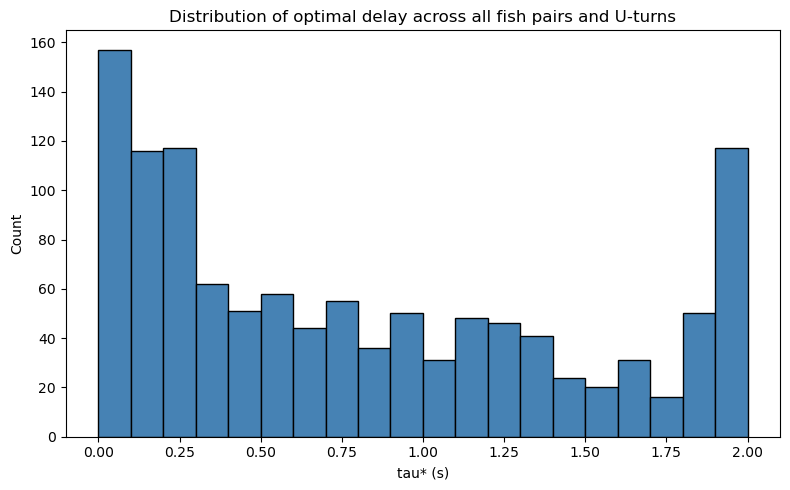

In [ ]:
if __name__ == '__main__':
    from data_access import get_experement_paths, split_at_nans

    data_path= get_experement_paths(group_size=5, limit=1)[0]
    data= pd.read_csv(data_path)
    clean_data= split_at_nans(data)

    chunk= max(clean_data, key=len)
    chunk= chunk.reset_index(drop=True)

    x0= chunk.iloc[:, 0].values
    y0= chunk.iloc[:, 1].values
    turns= find_turning_points(x0, y0)

    #collect all delay* values across all pairs and all turns
    all_delays = []

    for turn_start, _ in turns:
        if turn_start < 100 or turn_start + 100 > len(chunk):
            continue

        window  = chunk.iloc[turn_start - 100 : turn_start + 100]
        vectors = get_unit_vectors(window)

        for i in range(5):
            for j in range(5):
                if i == j:
                    continue
                C, delays_s = compute_Cij_matrix(vectors[i], vectors[j])
                if C.size == 0 or np.isnan(C).all():
                    continue
                best_delay = delays_s[int(np.argmax(np.nanmean(C, axis=1)))]
                all_delays.append(best_delay)

    # plot
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(all_delays, bins=20, range=(0, 2), color='steelblue', edgecolor='black')
    ax.set_xlabel('delay* (s)')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of optimal delay across all fish pairs and U-turns')
    plt.tight_layout()
    plt.show()